* **Source** - https://www.kaggle.com/competitions/playground-series-s6e9/data
* Description - Dataset Description
The dataset for this competition (both train and test) was inspired by the EV adoption Behavior dataset. Feature distributions are close to, but not exactly the same, as the original.
* **Files** -
* train.csv - the training set, with Will_Buy_EV as target
* test.csv - the test set, used to predict the probability for Will_Buy_EV
* sample_submission.csv - a sample submission file in the correct format

In [1]:
# Importing important libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
test = pd.read_csv('test.csv')
train = pd.read_csv('train.csv')
print(test.shape)
print(train.shape)

(286571, 14)
(668665, 15)


In [3]:
print('Train dataset ----: \n',train.head())
print('Test dataset ----: \n',test.head())

Train dataset ----: 
    id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66            92887.0              23.4                     2   
1   1   38            30000.0               5.0                     1   
2   2   26            94389.0              36.8                     1   
3   3   66            73580.0              23.7                     2   
4   4   54            57898.0              50.8                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                          1.0    Male  Suburban            Sedan   
1                     

In [4]:
print('Train dataset ----: \n',train.head())

Train dataset ----: 
    id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66            92887.0              23.4                     2   
1   1   38            30000.0               5.0                     1   
2   2   26            94389.0              36.8                     1   
3   3   66            73580.0              23.7                     2   
4   4   54            57898.0              50.8                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                          1.0    Male  Suburban            Sedan   
1                     

# Train

Introduction -

* This train data shows wether a person would buy a car or not based on their financial , lifestyle and EV-related characterstics

In [5]:
# so first i will use info function to get to know more about the data more like summary
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

Alternative Bulleted Version (Great for a report or notebook markdown cell):
Total Entries: 6,686,675 rows

Missing Values: None (0 null values)

Data Types: Verified and correct across all columns

In [6]:
# Now we will use describe functon to find errors if there are any 
train.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.000000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.103211,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.000000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.000000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.000000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.000000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.000000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


The data seems fairly clean and right already so there is no need of cleaning


We will use sql and pandas to find some important key information then we will make graphs then model 

In [7]:
conn = sqlite3.connect('ev_car.db')
train.to_sql('EV_car',conn,index = False , if_exists = 'replace')

668665

In [8]:
# Every query will answer one important question.

# Question 1 : Average income of each gender seprately
query1 = 'SELECT "Gender"  , AVG("Annual_Income_USD") as avg_annual FROM EV_car GROUP BY "Gender" ORDER BY "avg_annual" DESC  '
print('AVG ANUAL ENCOME OF EACH GENDER : \n',pd.read_sql_query(query1,conn))

# Question 2 : Average charging station near home of city types
query2 = 'SELECT "City_Type" , AVG("Charging_Stations_Near_Home") as avg_C_station FROM EV_car GROUP BY City_Type ORDER BY "avg_C_station" DESC'
print("AVG  NUMBER OF CHARGING STATION NEAR HOUS IN EACH CITY :\n", pd.read_sql_query(query2,conn).round(0))

# Question 3 : Annual encome of people who buyed car and those who not 
query3 = 'SELECT "Will_Buy_EV" , AVG("Annual_Income_USD") as avg_income FROM EV_car GROUP BY Will_Buy_EV ORDER BY avg_income DESC'
print("AVG INCOME OF PEOPLE WHO BUYED AND WHO DIDNT : \n",pd.read_sql_query(query3,conn))

# Question 4 : Average KM travelled with the anxiety to chck if it correlates
query4 = 'SELECT "Range_Anxiety_Level" , AVG("Daily_Commute_km") as avg_dist FROM EV_car GROUP BY Range_Anxiety_Level ORDER BY avg_dist DESC'
print(pd.read_sql_query(query4,conn)) 

AVG ANUAL ENCOME OF EACH GENDER : 
    Gender    avg_annual
0   Other  85298.095004
1  Female  85007.659388
2    Male  84570.269618
AVG  NUMBER OF CHARGING STATION NEAR HOUS IN EACH CITY :
   City_Type  avg_C_station
0     Urban            8.0
1  Suburban            4.0
2     Rural            1.0
AVG INCOME OF PEOPLE WHO BUYED AND WHO DIDNT : 
   Will_Buy_EV    avg_income
0         Yes  98827.302948
1          No  81794.588556
  Range_Anxiety_Level   avg_dist
0                High  52.916591
1              Medium  42.566057
2                 Low  31.005896


* **SQL Data Analysis:** Key Insights
1. Income & Purchasing Behavior
Income Disparity in EV Adoption: There is a clear financial divide when it comes to purchasing an electric vehicle. Consumers who bought an EV (Yes) have a significantly higher average income ($~98,827) compared to  those  who  did   not ($~81,794). This suggests that vehicle cost or purchasing power remains a major gating factor for EV adoption.

Gender Demographics: Average annual income remains relatively consistent across genders, hovering around $84,500 to $85,200. This indicates that gender alone does not heavily skew baseline earning power in this dataset.

2. Infrastructure & Environment
Urban vs. Rural Charging Access: Charging infrastructure density drops sharply outside of cities. Urban areas average 8 nearby charging stations, dropping to 4 in suburban areas, and hitting a sparse average of just 1 in rural areas. This highlights a massive infrastructure gap that likely impacts rural adoption rates.

3. Range Anxiety Analysis
Correlation with Distance: Range anxiety scales directly with distance. Individuals reporting a "High" range anxiety level travel an average distance of ~52.9 miles, compared to ~31.0 miles for those with "Low" anxiety. This proves that longer travel distances heavily amplify customer concerns regarding battery range.

# Pandas

In [9]:
# City type count
type_count = train["City_Type"].value_counts()
print(type_count)

# Anxiety level count
ax_count = train['Range_Anxiety_Level'].value_counts()
print('Anxiety level count :\n',ax_count)

# Count of people who will buy
buyer = train['Will_Buy_EV'].value_counts()
print(buyer)

City_Type
Urban       289305
Suburban    255377
Rural       123983
Name: count, dtype: int64
Anxiety level count :
 Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64
Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64


Categorical Distributions & Market Insights
1. City Type Distribution
Urban Dominance: The majority of the dataset resides in Urban environments (289,305 entries), followed closely by Suburban areas (255,377 entries), while Rural areas represent the smallest segment (123,983 entries).

Takeaway: The dataset is heavily skewed toward city and suburban dwellers, which aligns with the higher availability of charging infrastructure found in urban areas during earlier analysis.

2. Range Anxiety Level Breakdown
Overwhelmingly Low Anxiety: The vast majority of individuals report Low range anxiety (603,972 entries), with Medium anxiety sitting at 62,499 entries, and High anxiety being a very small minority (2,194 entries).

Takeaway: While distance correlates with higher anxiety levels, extreme range anxiety is rare across the general population in this dataset.

3. Target Variable (Will_Buy_EV) Distribution
Class Imbalance: The target variable shows a strong imbalance, with 551,886 non-buyers (No) compared to 116,779 confirmed EV buyers (Yes).

Takeaway: Non-buyers make up roughly 82% of the dataset. This class imbalance is crucial to note for model training, as models will need to account for this skew (using techniques like class weighting or proper evaluation metrics like F1-score/ROC-AUC) to avoid simply predicting "No" all the time.

# Plotting 

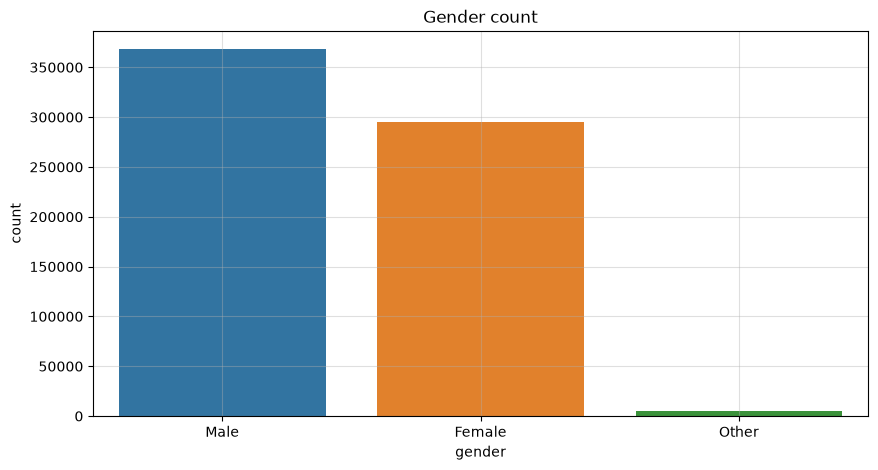

In [10]:
plt.figure(figsize = (10,5))
sns.countplot(data = train ,x = "Gender",hue = 'Gender')
plt.title('Gender count')
plt.xlabel('gender')
plt.ylabel('count')
plt.grid(True,alpha = 0.4)
plt.show()

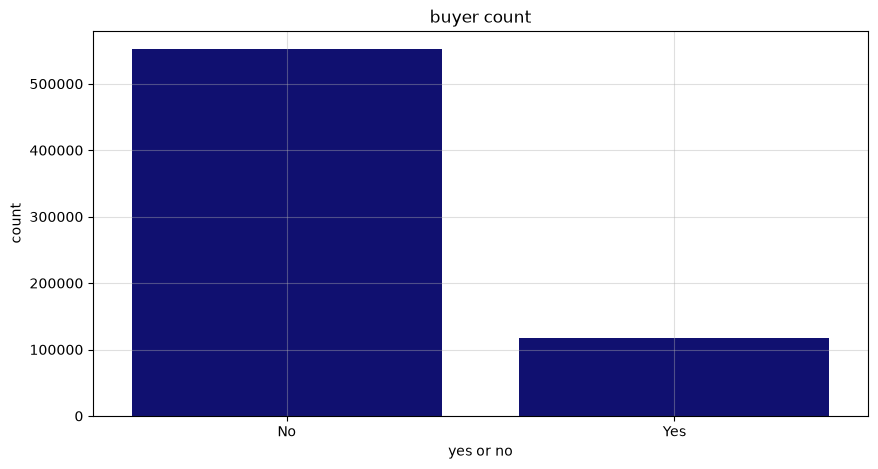

In [11]:
plt.figure(figsize = (10,5))
sns.countplot(data = train ,x = "Will_Buy_EV",color = '#000080')
plt.title('buyer count')
plt.xlabel('yes or no')
plt.ylabel('count')
plt.grid(True,alpha = 0.4)
plt.show()

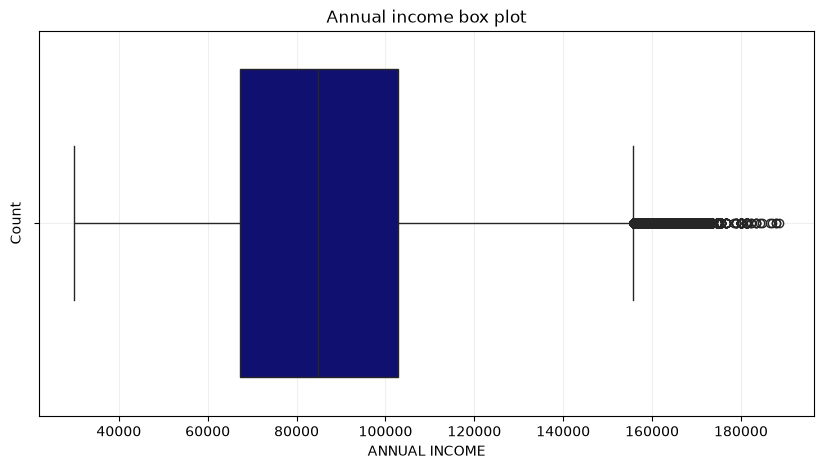

In [12]:
plt.figure(figsize = (10,5))
sns.boxplot(data = train , x = 'Annual_Income_USD' , color = '#000080')
plt.xlabel('ANNUAL INCOME')
plt.ylabel('Count')
plt.title('Annual income box plot')
plt.grid(True,alpha = 0.2)
plt.show()

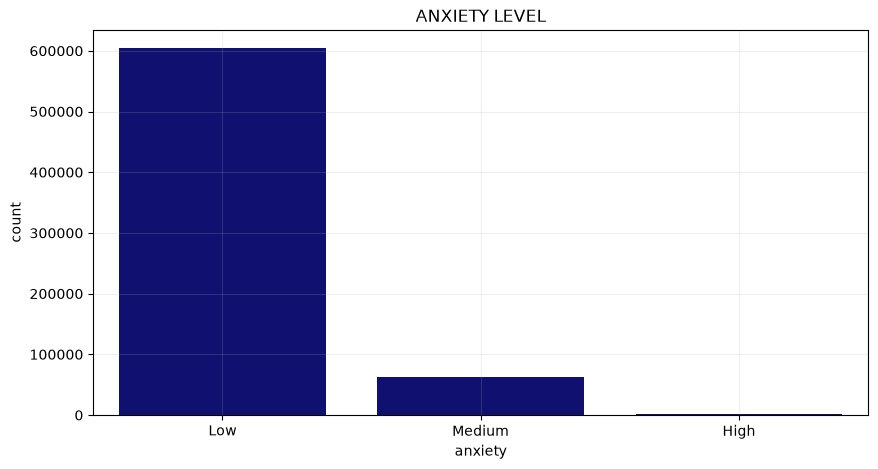

In [13]:
plt.figure(figsize = (10,5))
sns.countplot(data = train ,x = 'Range_Anxiety_Level', color = '#000080')
plt.title('ANXIETY LEVEL')
plt.xlabel('anxiety')
plt.ylabel('count')
plt.grid(True,alpha = 0.2)
plt.show()

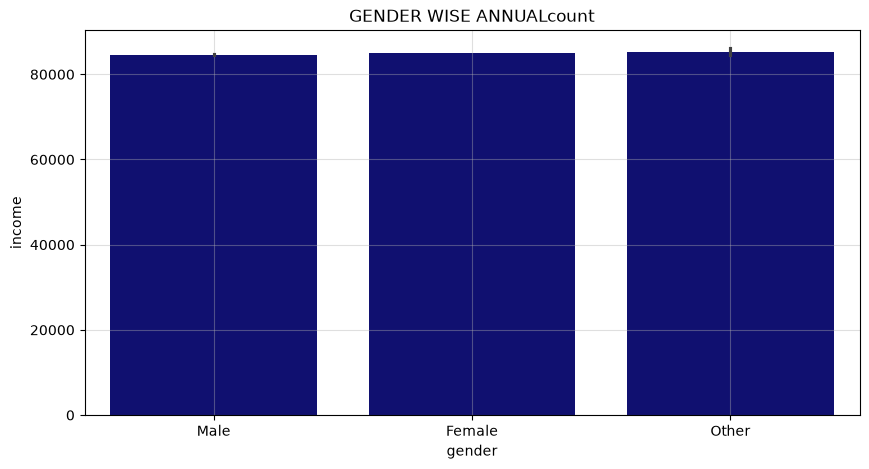

In [14]:
plt.figure(figsize = (10,5))
sns.barplot(data = train ,x = "Gender",y = 'Annual_Income_USD',color = '#000080')
plt.title('GENDER WISE ANNUALcount')
plt.xlabel('gender')
plt.ylabel('income')
plt.grid(True,alpha = 0.4)
plt.show()

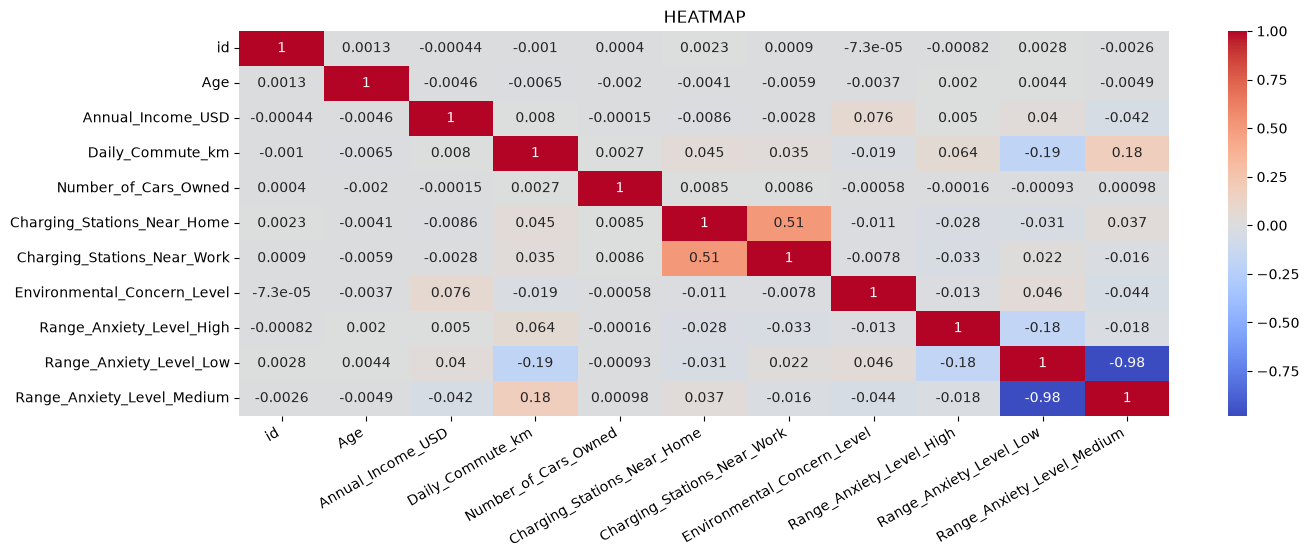

In [15]:
train = pd.get_dummies(train,columns = ['Range_Anxiety_Level'],dtype=int)
numeric = train.corr(numeric_only = True)
plt.figure(figsize = (15,5))
sns.heatmap(numeric , annot = True , cmap = 'coolwarm' )
plt.title('HEATMAP')
plt.xticks(rotation = 390,ha = 'right')
plt.show()

Data Anomaly Note: Correlation & Multicollinearity IssuesObservation:
* The correlation heatmap reveals that almost all continuous features (such as age, income, daily commute, and charging stations) have near-zero linear correlation (hovering around 0.0).
*    The Anomaly (Range Anxiety): A strong negative correlation of -0.98 appears between Range_Anxiety_Level_Low and Range_Anxiety_Level_Medium.
*     The Root Cause: This is not a genuine behavioral insight. It is a mathematical artifact caused by One-Hot Encoding, which splits a single categorical feature into multiple binary columns. Because an individual can only belong to one category, the columns are forced to be exact mathematical opposites.

# **ML MODEL**

In [22]:
# Importing important functions
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split , cross_val_score , GridSearchCV
from sklearn.metrics import roc_auc_score 
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Setup your data
x = train[['Annual_Income_USD', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']]
y = train[['Will_Buy_EV']]
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42            
)

param_grid = {
    "min_samples_split": [6, 8],
    "min_samples_leaf": [4, 6],
    "max_depth": [10, 12]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print('Best Parameter:', grid.best_params_)
print('Best CV Score:', grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:, 1]


roc_auc = roc_auc_score(y_test, y_prob)
print('ROC-AUC:', roc_auc)

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, pos_label='Yes') 
f1 = f1_score(y_test, y_pred, pos_label='Yes')

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Recall (for EV Buyers): {rec:.4f}")
print(f"Test F1-Score (for EV Buyers): {f1:.4f}")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

Best Parameter: {'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 6}
Best CV Score: 0.7749302845274424
ROC-AUC: 0.8799053721304064

Test Accuracy: 0.7757
Test Recall (for EV Buyers): 0.8438
Test F1-Score (for EV Buyers): 0.5661

Full Classification Report:
              precision    recall  f1-score   support

          No       0.96      0.76      0.85    110540
         Yes       0.43      0.84      0.57     23193

    accuracy                           0.78    133733
   macro avg       0.69      0.80      0.71    133733
weighted avg       0.87      0.78      0.80    133733



In [25]:
import joblib
from sklearn.tree import DecisionTreeClassifier

# Assuming your 'train' dataframe is already loaded in your environment
X = train[['Annual_Income_USD', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']]
y = train['Will_Buy_EV']

# Initialize model with the best parameters found
model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=6,
    min_samples_split=6,
    class_weight='balanced',
    random_state=42
)

# Train on full training data
model.fit(X, y)

# Save the trained model to a pkl file
joblib.dump(model, 'ev_model.pkl')
print("Model successfully saved as ev_model.pkl")

Model successfully saved as ev_model.pkl


In [27]:
%%writefile train_model.py
import joblib
from sklearn.tree import DecisionTreeClassifier

# Assuming your 'train' dataframe is already loaded
X = train[['Annual_Income_USD', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']]
y = train['Will_Buy_EV']

model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=6,
    min_samples_split=6,
    class_weight='balanced',
    random_state=42
)

model.fit(X, y)
joblib.dump(model, 'ev_model.pkl')
print("Model saved as ev_model.pkl")

Writing train_model.py
